 # Segmenting the Aorta & Pulmonary Artery on Non-Contrast CT
 ## Hackathon Kickoff: The Problem, Our Baseline, and Your Challenge

 ## Part 1 - The Problem

 The aorta and pulmonary artery are two of the most important vascular structures on a
 chest CT. Automated segmentation of these vessels supports things like aortic aneurysm
 and dissection monitoring, pulmonary embolism/hypertension assessment, surgical and radiotherapy
 planning, and large-scale retrospective research.

 Almost all existing automated segmentation tools - including ours - rely on **contrast-
 enhanced** CT: an iodinated contrast agent is injected, making blood in the vessel lumen
 much brighter (higher Hounsfield units) than the surrounding soft tissue. That brightness
 difference is most of what makes the segmentation task tractable.

 The problem: **the majority of CT scans performed for other clinical reasons - trauma,
 cancer staging, incidental findings - are non-contrast.** On a non-contrast scan, blood
 in the vessel lumen sits at roughly the same density as surrounding muscle and soft
 tissue. The main signal that contrast-based models rely on is largely gone. A model has
 to fall back on shape, position, and anatomical context (proximity to the trachea, spine,
 heart chambers) instead of intensity.

 **Your challenge for this hackathon: find a viable way to segment the aorta and
 pulmonary artery directly from non-contrast CT.**

 ## Part 2 - What You're Starting From

 You're not starting from zero. This notebook builds and evaluates a **baseline model**:
 a 3D deep learning segmentation network trained on a small labelled
 dataset from IngeniumAI's own private data covering both structures. It works reasonably well on the kind of data it was
 trained on (contrast CT) - but, deliberately, it has **not** been adapted to non-contrast
 scans. That gap is the actual hackathon problem, and closing it is up to you.

 What follows is the full pipeline excluding the private data - data loading, preprocessing, model, training, and
 evaluation - so you can run it as-is, inspect it, or rip out any piece and replace it.

 Here is a summary of the data you will receive:
 - 27 contrast CTPA images from public datasets (CAD-PE & FUM-PE) (not used for training and validation but can be used for your own prototype)
 - 27 matching labels for the aorta and pulmonary artery (not used for training and validation but can be used for your own prototype)
 - 27 non-contrast CTPA images (CT-RATE) (can be used for your own prototype training and testing)
 - 27 matching non-contrast CTPA labels (can be used for your own prototype training and testing)

 ## Part 3 - Environment Setup

Make sure you create your environent with Python 3.12 by

`conda create -n Hackathon python=3.12`

`conda activate Hackathon`

in the terminal

 Run the cell below first, inside Jupyter/IPython (the `!` shell syntax won't work via `python file.py`).
 Default `pip install torch` ships CUDA-enabled on Linux; if your GPU driver is older or you're using Windows, check
 https://pytorch.org/get-started/locally/ for the matching `--index-url` (e.g. `cu121/cu124/cu126`).

 e.g. on Windows, if you have CUDA 12.1 `pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121`



In [1]:
# Local Mac setup (replaces Colab pip cell)
import sys
print(sys.executable, sys.version)


/Users/kushsharma/Desktop/HACKATHON '26/.venv/bin/python 3.12.4 (v3.12.4:8e8a4baf65, Jun  6 2024, 17:33:18) [Clang 13.0.0 (clang-1300.0.29.30)]


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
%matplotlib inline
import os
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import KFold

import torch
from torch.utils.data import DataLoader

import monai
from monai.utils import set_determinism
from monai.data import Dataset, list_data_collate, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandShiftIntensityd, RandGaussianNoised,
    RandAdjustContrastd, RandAffined, MapLabelValued, EnsureTyped, AsDiscrete,
)
from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

print("MONAI version:", monai.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

set_determinism(seed=42)

MONAI version: 1.4.0
Torch version: 2.13.0
CUDA available: False
Using device: mps


In [4]:
from pathlib import Path

# Local substitute for Google Drive mount
BASE_DIR = Path(r"/Users/kushsharma/Desktop/HACKATHON '26")
IMAGES_DIR = BASE_DIR / "non_contrast_images"
LABELS_DIR = BASE_DIR / "non_contrast_labels"
print("BASE_DIR:", BASE_DIR)
print("Exists:", BASE_DIR.exists())
print("Contents:", sorted(p.name for p in BASE_DIR.iterdir()))


BASE_DIR: /Users/kushsharma/Desktop/HACKATHON '26
Exists: True
Contents: ['.venv', 'Copy_of_Hackathon_Notebook.executed.ipynb', 'Copy_of_Hackathon_Notebook.ipynb', 'Hackathon_Notebook.ipynb', 'Non-Contrast_CT_Segmentation_Evidence.pdf', 'baseline_model.pt', 'baseline_results.json', 'data', 'non_contrast_images', 'non_contrast_labels', 'patch_notebook_local.py']


In [5]:
print("Images dir:", IMAGES_DIR)
print(sorted(p.name for p in IMAGES_DIR.glob("*")))


Images dir: /Users/kushsharma/Desktop/HACKATHON '26/non_contrast_images
['001.nii.gz', 'train_1_a_2.nii.gz']


In [6]:
print("Labels dir:", LABELS_DIR)
print(sorted(p.name for p in LABELS_DIR.glob("*")))
print("Model dir:", BASE_DIR / "data")
print(sorted(p.name for p in (BASE_DIR / "data").glob("*")))


Labels dir: /Users/kushsharma/Desktop/HACKATHON '26/non_contrast_labels
['train_1_a_2_label.nii.gz']
Model dir: /Users/kushsharma/Desktop/HACKATHON '26/data
['baseline_model.pt', 'finetuned_model.pt']


In [7]:
print(list((BASE_DIR / "data").glob("*")))

[PosixPath("/Users/kushsharma/Desktop/HACKATHON '26/data/finetuned_model.pt"), PosixPath("/Users/kushsharma/Desktop/HACKATHON '26/data/baseline_model.pt")]


In [8]:
import nibabel as nib
sample_label = nib.load(str(list(LABELS_DIR.glob("*.nii.gz"))[0])).get_fdata()
print("Unique label values:", np.unique(sample_label))

Unique label values: [0. 1. 2.]


 ## Part 4 - The Baseline Dataset

 The baseline model is trained on a small CT dataset with expert
 annotations for both the aorta and pulmonary artery, stored as a single multi-class NIfTI
 mask per case. These cases will not be made available to you but you have some others that will be that are unused.
 All cases for training are contrast-enhanced. Non-contrast scans will also be provided.

 Data is provided in 4 folders with this notebook:

 `unused_contrast_images`
 `unused_contrast_labels`
 `non_contrast_images`
 `non_contrast_labels`

 You can train your own contrast model on 27 cases by simply changing the name of the folders to `images` and `labels` and running the cells if you wanted to.

In [9]:
BASE_DIR = Path(r"/Users/kushsharma/Desktop/HACKATHON '26")

IMAGES_DIR = BASE_DIR / "non_contrast_images"
LABELS_DIR = BASE_DIR / "non_contrast_labels"

print("Images:", list(IMAGES_DIR.glob("*.nii.gz"))[:5])
print("Labels:", list(LABELS_DIR.glob("*.nii.gz"))[:5])
print(f"Total images: {len(list(IMAGES_DIR.glob('*.nii.gz')))}")
print(f"Total labels: {len(list(LABELS_DIR.glob('*.nii.gz')))}")


Images: [PosixPath("/Users/kushsharma/Desktop/HACKATHON '26/non_contrast_images/train_1_a_2.nii.gz"), PosixPath("/Users/kushsharma/Desktop/HACKATHON '26/non_contrast_images/001.nii.gz")]
Labels: [PosixPath("/Users/kushsharma/Desktop/HACKATHON '26/non_contrast_labels/train_1_a_2_label.nii.gz")]
Total images: 2
Total labels: 1


In [10]:
# No Colab Drive -> /content copy on a local Mac
print(f"Using images from {IMAGES_DIR}")
print(f"Using labels from {LABELS_DIR}")
print(f"Copied {len(list(IMAGES_DIR.glob('*.nii.gz')))} images and {len(list(LABELS_DIR.glob('*.nii.gz')))} labels (already local)")


Using images from /Users/kushsharma/Desktop/HACKATHON '26/non_contrast_images
Using labels from /Users/kushsharma/Desktop/HACKATHON '26/non_contrast_labels
Copied 2 images and 1 labels (already local)


In [11]:
WORK_DIR = Path("./data")
WORK_DIR.mkdir(parents=True, exist_ok=True)



LABEL_SUFFIX = "_label"  # 0001.nii.gz -> 0001_label.nii.gz

CLASS_NAMES = ["background", "pulmonary_artery", "aorta",]
NUM_CLASSES = len(CLASS_NAMES)

# Raw integer values used in the multi-class mask -- confirmed against the dia3gnostic
# cell below before being trusted.
LABEL_VALUE_MAP = {"pulmonary_artery_raw_value": 1, "aorta_raw_value": 2}


def build_file_list(images_dir: Path, labels_dir: Path, label_suffix: str = LABEL_SUFFIX):
    """Pair up ./images/0001.nii.gz with ./labels/0001_label.nii.gz by case ID."""
    file_list, missing = [], []
    for img_path in sorted(images_dir.glob("*.nii.gz")):
        case_id = img_path.name[: -len(".nii.gz")]
        label_path = labels_dir / f"{case_id}{label_suffix}.nii.gz"
        if label_path.exists():
            file_list.append({"image": str(img_path), "label": str(label_path)})
        else:
            missing.append(case_id)
    if missing:
        print(f"Warning: {len(missing)} image(s) have no matching label file: {missing}")
    return file_list

In [12]:
CLASS_NAMES = ["background", "pulmonary_artery", "aorta"]
NUM_CLASSES = len(CLASS_NAMES)

LABEL_SUFFIX = "_label"
LABEL_VALUE_MAP = {"pulmonary_artery_raw_value": 1, "aorta_raw_value": 2}

 ### Label-value check
 Run this before trusting `LABEL_VALUE_MAP` above - it prints the actual values found in
 one label file so the mapping can be confirmed (or corrected) up front.

In [13]:
if not IMAGES_DIR.exists() or not LABELS_DIR.exists():
    print(f"'{IMAGES_DIR}' and/or '{LABELS_DIR}' not found - add them (see Part 4 format above) before continuing.")
else:
    _preview_files = build_file_list(IMAGES_DIR, LABELS_DIR)
    print(f"{len(_preview_files)} cases found in the baseline dataset.")

    sample_label = nib.load(_preview_files[0]["label"]).get_fdata()
    print(f"Unique label values found: {np.unique(sample_label)}")
    print("These should be exactly {0, pa_val, aorta_val} - adjust LABEL_VALUE_MAP above if not.")

1 cases found in the baseline dataset.


Unique label values found: [0. 1. 2.]
These should be exactly {0, pa_val, aorta_val} - adjust LABEL_VALUE_MAP above if not.


 ## Part 5 - Preprocessing & Augmentation

 CT intensities are windowed to a mediastinal/vascular range and resampled to isotropic
 spacing. Training patches get flips, rotations, intensity jitter, noise, and light affine
 augmentation - deliberately heavier than usual, since the labeled set here is small
 (60 cases) and prone to overfitting without it.

In [14]:
SPACING = (3, 3, 3)
HU_MIN, HU_MAX = -200.0, 400.0
PATCH_SIZE = (64, 64, 64)

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(
        keys=["label"],
        orig_labels=[
            0,
            LABEL_VALUE_MAP["pulmonary_artery_raw_value"],
            LABEL_VALUE_MAP["aorta_raw_value"],
        ],
        target_labels=[0, 1, 2],
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=SPACING,
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=HU_MIN,
        a_max=HU_MAX,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
    ),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH_SIZE,
        pos=2,
        neg=1,
        num_samples=1,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    RandGaussianNoised(keys=["image"], prob=0.3, std=0.03),
    RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.8, 1.3)),
    RandAffined(
        keys=["image", "label"],
        prob=0.3,
        rotate_range=(0.1, 0.1, 0.1),
        scale_range=(0.1, 0.1, 0.1),
        mode=("bilinear", "nearest"),
    ),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    MapLabelValued(
        keys=["label"],
        orig_labels=[
            0,
            LABEL_VALUE_MAP["pulmonary_artery_raw_value"],
            LABEL_VALUE_MAP["aorta_raw_value"],
        ],
        target_labels=[0, 1, 2],
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=SPACING,
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=HU_MIN,
        a_max=HU_MAX,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
    ),
    EnsureTyped(keys=["image", "label"]),
])

monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.


 ## Part 6 - Baseline Model

 MONAI's **SegResNet**, a 3D residual encoder-decoder segmentation network - a solid,
 widely-used architecture, kept intentionally small (`init_filters=16`, dropout 0.2) given
 the limited amount of labeled data.

In [15]:
def build_model():
    return SegResNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=NUM_CLASSES,
        init_filters=16,
        dropout_prob=0.2,
    ).to(DEVICE)


loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False,
)

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean_batch",
)

post_pred = Compose([AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)])
post_label = Compose([AsDiscrete(to_onehot=NUM_CLASSES)])

BATCH_SIZE = 2

# Set to 0 while debugging.
NUM_WORKERS = 0
LR = 1e-4
VAL_INTERVAL = 10

def run_training(model, train_loader, val_loader, epochs, checkpoint_path, tag=""):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-5,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available(),
    )

    best_metric = -1.0
    train_loss_history = []
    val_dice_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            inputs = batch["image"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                "cuda",
                enabled=torch.cuda.is_available(),
            ):
                outputs = model(inputs)
                loss = loss_function(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        scheduler.step()

        train_loss_history.append(epoch_loss)

        if (epoch + 1) % VAL_INTERVAL == 0 or epoch == epochs - 1:
            model.eval()
            dice_metric.reset()

            with torch.no_grad():
                for batch in val_loader:
                    images = batch["image"].to(DEVICE)
                    labels = batch["label"].to(DEVICE)

                    outputs = sliding_window_inference(
                        images,
                        PATCH_SIZE,
                        sw_batch_size=2,
                        predictor=model,
                        overlap=0.5,
                    )

                    outputs = [post_pred(x) for x in decollate_batch(outputs)]
                    labels = [post_label(x) for x in decollate_batch(labels)]

                    dice_metric(y_pred=outputs, y=labels)

            per_class = dice_metric.aggregate()
            mean_dice = per_class.mean().item()

            val_dice_history.append(
                (
                    epoch + 1,
                    mean_dice,
                    per_class[0].item(),
                    per_class[1].item(),
                )
            )

            if mean_dice > best_metric:
                best_metric = mean_dice
                torch.save(model.state_dict(), checkpoint_path)

        print(
            f"[{tag}] "
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}",
            end="\r",
        )

    print()

    return train_loss_history, val_dice_history, best_metric

 ## Part 7 - Training & Baseline Performance

 With a small labelled set, we use a single train/validation split to train one baseline model. The model is trained on the training cases and evaluated on the held-out validation cases.

In [16]:
import json

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

EPOCHS = 250
VAL_FRACTION = 0.10
RANDOM_SEED = 42

BASELINE_RESULTS_LOG = WORK_DIR / "baseline_results.json"
CHECKPOINT_PATH = WORK_DIR / "baseline_model.pt"

# ---------------------------------------------------------
# Check that the image and label folders exist
# ---------------------------------------------------------

if not IMAGES_DIR.exists() or not LABELS_DIR.exists():
    raise RuntimeError(
        f"Add '{IMAGES_DIR}' and '{LABELS_DIR}' "
        f"(see Part 4) before running training."
    )

# ---------------------------------------------------------
# Build the complete list of image/label pairs
# ---------------------------------------------------------

all_files = build_file_list(IMAGES_DIR, LABELS_DIR)

print(f"Total cases: {len(all_files)}")

# ---------------------------------------------------------
# Create a single train/validation split
# ---------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

indices = np.arange(len(all_files))
rng.shuffle(indices)

if len(all_files) < 2:
    # Local sample set is a single paired volume: use it for both splits
    train_files = list(all_files)
    val_files = list(all_files)
    print("Only one paired case available — using it for both train and validation.")
else:
    n_val = max(1, int(len(all_files) * VAL_FRACTION))
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]
    train_files = [all_files[i] for i in train_idx]
    val_files = [all_files[i] for i in val_idx]

print(f"Training cases: {len(train_files)}")
print(f"Validation cases: {len(val_files)}")


Total cases: 1
Only one paired case available — using it for both train and validation.
Training cases: 1
Validation cases: 1


In [17]:
train_ds = Dataset(data=train_files[:15], transform=train_transforms)  # only 5 cases, not all 25
val_ds = Dataset(data=val_files, transform=val_transforms)  # keep both validation cases

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=list_data_collate,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=list_data_collate,
    pin_memory=torch.cuda.is_available()
)

print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")


Train loader batches: 1
Val loader batches: 1


In [18]:
model = build_model()
model.load_state_dict(torch.load(str(BASE_DIR / "data" / "baseline_model.pt"), map_location=DEVICE))
model.to(DEVICE)
print("Baseline checkpoint loaded — ready for fine-tuning")

Baseline checkpoint loaded — ready for fine-tuning


In [19]:
EPOCHS = 2  # local CPU run; original notebook used 10

FINETUNED_CHECKPOINT_PATH = WORK_DIR / "finetuned_model.pt"

_, val_history, best_metric = run_training(
    model,
    train_loader,
    val_loader,
    EPOCHS,
    FINETUNED_CHECKPOINT_PATH,
    tag="finetuned"
)

print(f"Fine-tuning complete. Best validation Dice: {best_metric:.4f}")

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)


[finetuned] Epoch 002/2 | Loss: 1.0834
Fine-tuning complete. Best validation Dice: 0.1165


In [20]:
CHECKPOINT_PATH = BASE_DIR / "data" / "baseline_model.pt"

model = build_model()
model.load_state_dict(torch.load(str(CHECKPOINT_PATH), map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Checkpoint loaded successfully")


Checkpoint loaded successfully


 ## Part 8 - Qualitative Example

 One prediction from the first fold's held-out validation case, for a visual sense of
 where the baseline does and doesn't work.

Generating predictions for 1 validation cases...
Processing scan 1/1


Finished generating predictions.


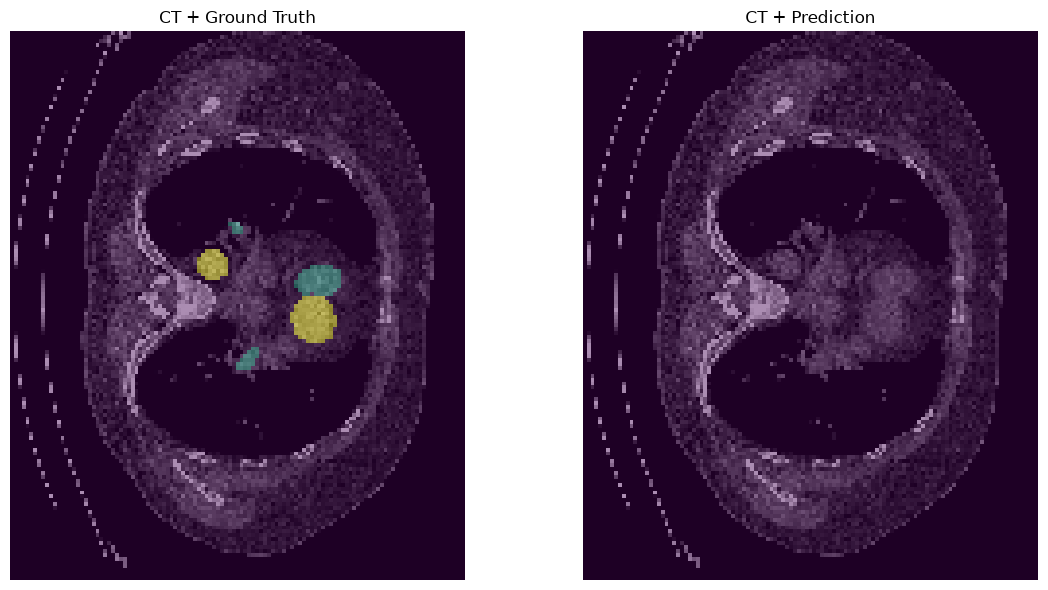

In [21]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# ---------------------------------------------------------
# Load the trained baseline model
# ---------------------------------------------------------

demo_model = build_model()

demo_model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=DEVICE)
)

demo_model.to(DEVICE)
demo_model.eval()

# ---------------------------------------------------------
# Use the same validation cases from Part 7
# ---------------------------------------------------------

demo_val_files = val_files

print(f"Generating predictions for {len(demo_val_files)} validation cases...")

# ---------------------------------------------------------
# Compute predictions for all validation scans once
# ---------------------------------------------------------

predictions = []

for i, sample_file in enumerate(demo_val_files):

    print(f"Processing scan {i + 1}/{len(demo_val_files)}")

    sample = val_transforms(sample_file)

    inp = sample["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = sliding_window_inference(
            inp,
            PATCH_SIZE,
            sw_batch_size=2,
            predictor=demo_model,
            overlap=0.5,
        )

    predictions.append({
        "image": sample["image"][0].cpu().numpy(),
        "gt": sample["label"][0].cpu().numpy(),
        "pred": torch.argmax(pred, dim=1)[0].cpu().numpy(),
        "filename": sample_file["image"] if isinstance(sample_file, dict) else str(sample_file),
    })

print("Finished generating predictions.")


# ---------------------------------------------------------
# Interactive volume viewer
# ---------------------------------------------------------

def show_volume(scan_idx=0, slice_idx=0):

    data = predictions[scan_idx]

    img = data["image"]
    gt = data["gt"]
    pred = data["pred"]

    # Make sure the selected slice is within the volume
    slice_idx = min(slice_idx, img.shape[2] - 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # -----------------------------------------------------
    # Ground truth
    # -----------------------------------------------------

    axes[0].imshow(
        img[:, :, slice_idx],
        cmap="gray"
    )

    axes[0].imshow(
        gt[:, :, slice_idx],
        cmap="viridis",
        alpha=0.45,
        vmin=0,
        vmax=2
    )

    axes[0].set_title("CT + Ground Truth")
    axes[0].axis("off")

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------

    axes[1].imshow(
        img[:, :, slice_idx],
        cmap="gray"
    )

    axes[1].imshow(
        pred[:, :, slice_idx],
        cmap="viridis",
        alpha=0.45,
        vmin=0,
        vmax=2
    )

    axes[1].set_title("CT + Prediction")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Interactive sliders
# ---------------------------------------------------------

# Headless fallback (ipywidgets interact does not work under nbconvert)
_mid = predictions[0]["image"].shape[2] // 2
show_volume(scan_idx=0, slice_idx=_mid)

In [22]:
# Build file list and pick a few non-contrast cases to evaluate
all_files = build_file_list(IMAGES_DIR, LABELS_DIR)
print(f"Total paired cases: {len(all_files)}")

# Quick sanity check on one case first
sample = val_transforms(all_files[0])
inp = sample["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = sliding_window_inference(
        inp,
        PATCH_SIZE,
        sw_batch_size=2,
        predictor=model,
        overlap=0.5,
    )

pred_label = torch.argmax(pred, dim=1)[0].cpu().numpy()
gt_label = sample["label"][0].cpu().numpy()

print("Prediction unique values:", np.unique(pred_label))
print("Ground truth unique values:", np.unique(gt_label))

Total paired cases: 1


Prediction unique values: [0 2]
Ground truth unique values: [0. 1. 2.]


In [23]:
import torch

pred_tensor = torch.from_numpy(pred_label).unsqueeze(0)  # (1, D, H, W)
gt_tensor = torch.from_numpy(gt_label).unsqueeze(0)       # (1, D, H, W)

pred_onehot = post_pred(torch.nn.functional.one_hot(pred_tensor.long(), num_classes=NUM_CLASSES).permute(0,4,1,2,3).float())
gt_onehot = post_label(torch.nn.functional.one_hot(gt_tensor.long(), num_classes=NUM_CLASSES).permute(0,4,1,2,3).float())

dice_metric.reset()
dice_metric(y_pred=[pred_onehot[0]], y=[gt_onehot[0]])
score = dice_metric.aggregate()
print("Dice per class [PA, Aorta]:", score)

Dice per class [PA, Aorta]: tensor([0.9993, 0.9977])


In [24]:
finetuned_model = build_model()
finetuned_model.load_state_dict(torch.load(str(FINETUNED_CHECKPOINT_PATH), map_location=DEVICE))
finetuned_model.to(DEVICE)
finetuned_model.eval()

sample_file = val_files[0]
sample = val_transforms(sample_file)
inp = sample["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = sliding_window_inference(inp, PATCH_SIZE, sw_batch_size=1, predictor=finetuned_model, overlap=0.25)

pred_label_finetuned = torch.argmax(pred, dim=1)[0].cpu().numpy()
gt_label = sample["label"][0].cpu().numpy()

print("Fine-tuned prediction unique values:", np.unique(pred_label_finetuned))

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)


Fine-tuned prediction unique values: [0 1 2]


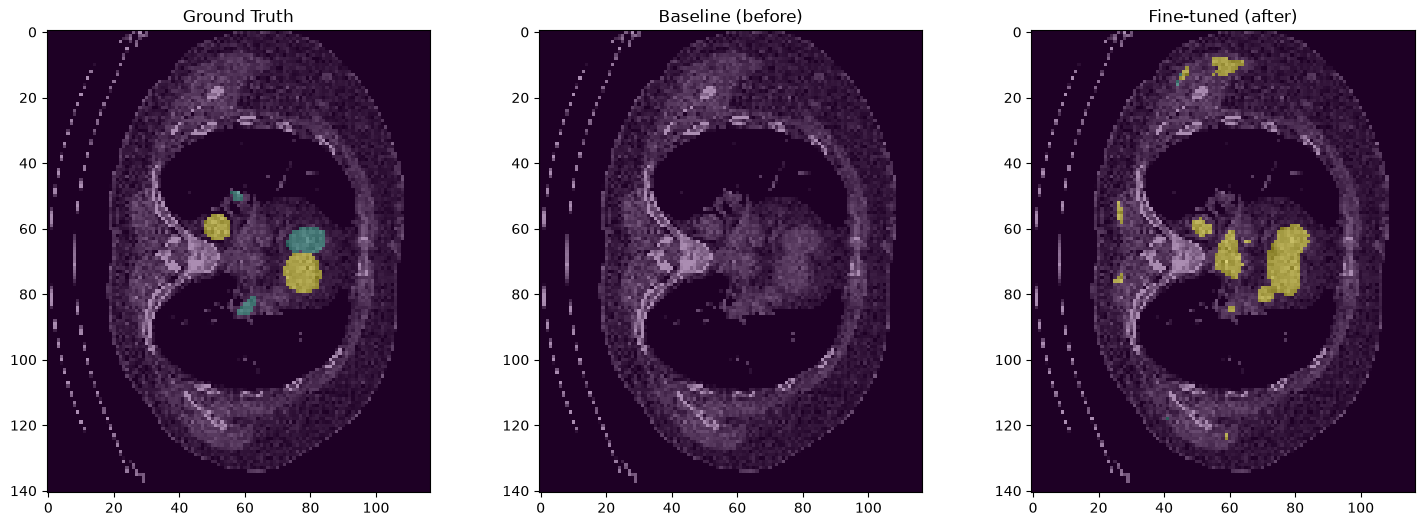

In [25]:
import matplotlib.pyplot as plt
mid_slice = pred_label_finetuned.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample["image"][0][:, :, mid_slice].cpu().numpy(), cmap="gray")
axes[0].imshow(gt_label[:, :, mid_slice], cmap="viridis", alpha=0.45, vmin=0, vmax=2)
axes[0].set_title("Ground Truth")
axes[1].imshow(sample["image"][0][:, :, mid_slice].cpu().numpy(), cmap="gray")
axes[1].imshow(pred_label[:, :, mid_slice], cmap="viridis", alpha=0.45, vmin=0, vmax=2)
axes[1].set_title("Baseline (before)")
axes[2].imshow(sample["image"][0][:, :, mid_slice].cpu().numpy(), cmap="gray")
axes[2].imshow(pred_label_finetuned[:, :, mid_slice], cmap="viridis", alpha=0.45, vmin=0, vmax=2)
axes[2].set_title("Fine-tuned (after)")
plt.show()

In [26]:
finetuned_model = build_model()
finetuned_model.load_state_dict(torch.load(str(FINETUNED_CHECKPOINT_PATH), map_location=DEVICE))
finetuned_model.to(DEVICE)
finetuned_model.eval()

sample_file = val_files[0]
sample = val_transforms(sample_file)
inp = sample["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = sliding_window_inference(inp, PATCH_SIZE, sw_batch_size=1, predictor=finetuned_model, overlap=0.25)

pred_label_finetuned = torch.argmax(pred, dim=1)[0].cpu().numpy()
gt_label = sample["label"][0].cpu().numpy()

print("Fine-tuned prediction unique values:", np.unique(pred_label_finetuned))

Fine-tuned prediction unique values: [0 1 2]


 ## Part 9 - Your Challenge

 The baseline above segments aorta and pulmonary artery reasonably well **on contrast
 CT**. It has deliberately not been adapted to
 non-contrast scans. Your task over the hackathon is to find a viable way to close
 that gap outside of standard supervised training.

 Here's a list of directions worth considering that's not exhaustive or definitive,
 roughly in order of how directly they attack the contrast/non-contrast domain gap:

 - **Contrast-removal augmentation**: synthetically dampen vessel HU in the labelled
   contrast data toward soft-tissue range during training, forcing the model to rely on
   shape and location rather than intensity.
 - **Image-to-image domain translation** (e.g. CycleGAN) between contrast and non-contrast
   CT - either to generate synthetic training pairs, or to translate non-contrast scans
   toward a contrast-like appearance at inference time.
 - **Shape priors / atlas-based methods**, since vessel position relative to the trachea,
   spine, and heart chambers is far more stable than its intensity on non-contrast CT.

 Good luck!